# 2026-04-22_inference_SHAMe_best-rand30.ipynb

Noisy inference on the SHAMe OOD mock, same setup as `2026-04-05_inference_best-rand30.ipynb` (four statistics combinations, checkpoints under `results_sbi/sbi<...>_best-rand30`).

**Corner plots** ($\omega_{\rm cold}$, $\sigma_8$, $b_1$) for each number density, in order **small → large** n̄: `_nbar0.00011`, `_nbar0.00022`, `_nbar0.00054`.

The **overlay figures** stack those three mocks for each statistics set; colors are three shades of that set’s entry in `utils_plot.color_dict_statistics` (pk / pk+pgm / pk+bispec / pk+bispec+pgm). Fiducial markers match each n̄.


In [1]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

%load_ext autoreload
%autoreload 2

In [2]:
# Shared configuration (matches 2026-04-05_inference_best-rand30)
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnest_p4_n320000"
TAG_BIASPARAMS_TRAIN_NOISY = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"

tag_reparam = "_rp"
statistics_arr = [["pk"], ["pk", "pgm"], ["pk", "bispec"], ["pk", "bispec", "pgm"]]
tags_mask_inf = ["", "", "_kb0.25", "_kb0.25"]
tag_stats_arr = [f'_{"_".join(s)}' for s in statistics_arr]

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}

extents_mid = extents.copy()
extents_mid['b1'] = [-0.4, 1.4]

extents_narrow = extents.copy()
extents_narrow['b1'] = [0.2, 0.7]
extents_narrow['sigma8_cold'] = [0.7, 0.9]

DATA_MODE_TEST_SHAME = "shame"
# smallest → largest n̄ (utils_model.bias_dict_shame)
TAG_MOCK_SHAME_LIST = ["_nbar0.00011", "_nbar0.00022", "_nbar0.00054"]
NBAR_LABELS = ["0.00011", "0.00022", "0.00054"]

PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1"]

idx_obs = 0


## Noisy inference — SHAMe OOD

In [3]:
tags_inf_noisy, labels_noisy, colors_noisy, _ = utils_plot.setup_inference_tags(
    data_mode=data_mode,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    statistics_arr=statistics_arr,
    bx=bx,
    tag_noise=TAG_NOISE_TRAIN,
    tag_reparam=tag_reparam,
    n_train=n_train,
    tags_mask=tags_mask_inf,
)
tags_inf_noisy = [t + TAG_INF_BEST_SUFFIX for t in tags_inf_noisy]

cosmo_param_names_vary_n, bias_param_names_vary_n, param_names_vary_n = utils_plot.load_training_params(
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN_NOISY,
    bx=bx,
)

inf_methods_noisy = ["sbi"] * len(tags_inf_noisy)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00011_pred.npy


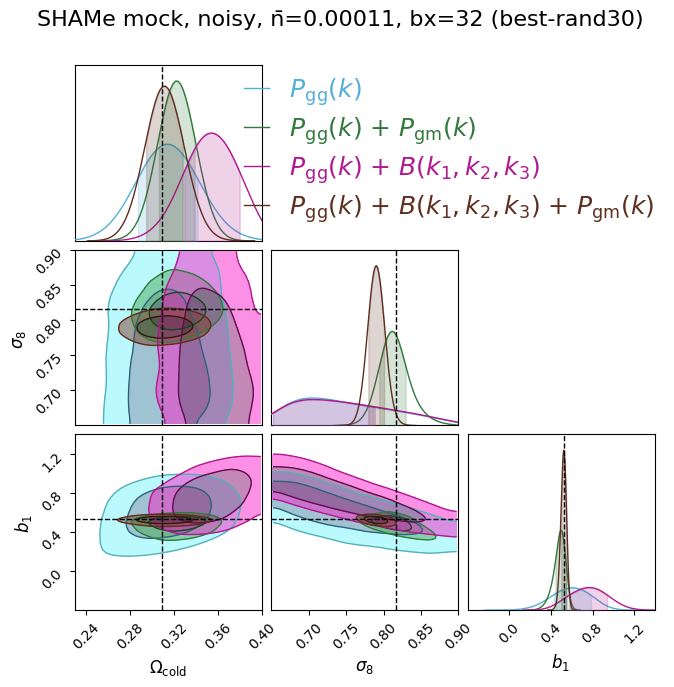

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


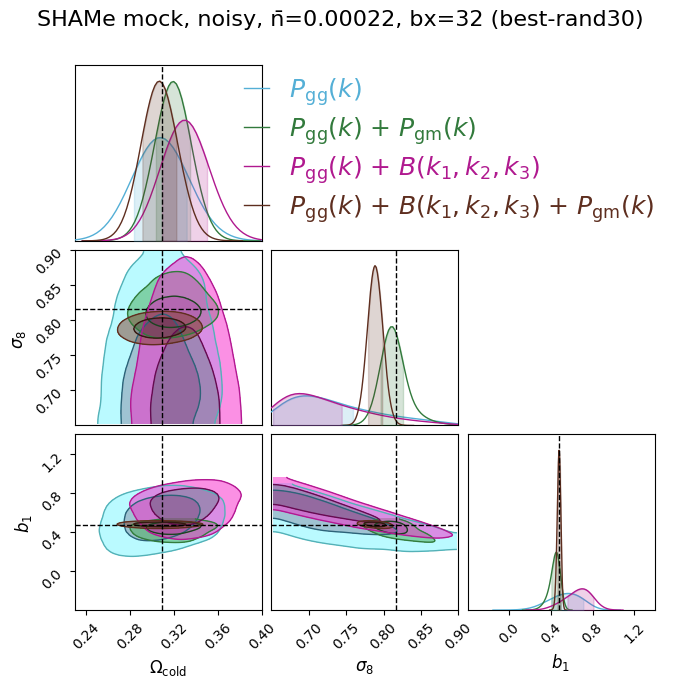

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00054_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00054_pred.npy


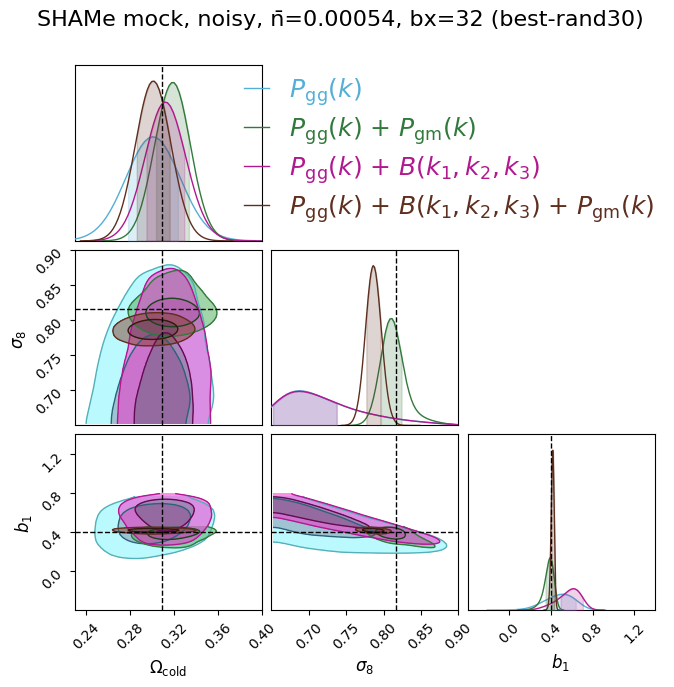

In [6]:
tag_stats_shame = [f'_{"_".join(s)}' + "".join(m) for s, m in zip(statistics_arr, tags_mask_inf)]

for tag_mock, nbar_label in zip(TAG_MOCK_SHAME_LIST, NBAR_LABELS):
    tags_test_shame = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_shame,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=tag_mock,
    )

    theta_ood = data_loader.load_theta_ood(
        DATA_MODE_TEST_SHAME,
        tag_mock,
        cosmo_param_names_vary=cosmo_param_names_vary_n,
        bias_param_names_vary=bias_param_names_vary_n,
    )

    theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
    idxs_zoom = [param_names_vary_n.index(pn) for pn in PARAM_NAMES_ZOOM]
    theta_obs_true_show = theta_obs_true[idxs_zoom]

    title_base = (
        f"SHAMe mock, noisy, n̄={nbar_label}, bx={bx} (best-rand30)"
    )

    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_obs_true_show,
        inf_methods=inf_methods_noisy,
        tags_inf=tags_inf_noisy,
        tags_test=tags_test_shame,
        colors=colors_noisy,
        labels=labels_noisy,
        title=title_base,
        extents=extents_mid,
        unreparameterize=True,
    )


## Three n̄ on one figure (each statistics set)

For each training statistics combination, the same noisy `best-rand30` checkpoint is evaluated on the three SHAMe mocks. **Contour colors:** light → dark with increasing n̄, from three shades of the corresponding `color_dict_statistics` color (cyan / green / magenta / brown families). **Axis ranges:** `extents_mid` ($b_1 \in [-0.4, 1.4]$, other bounds from `extents`) for the per-n̄ four-statistics figures and for pk / pk+bispec overlays; `extents_narrow` for the pk+pgm and pk+bispec+pgm overlays only.


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00054_pred.npy


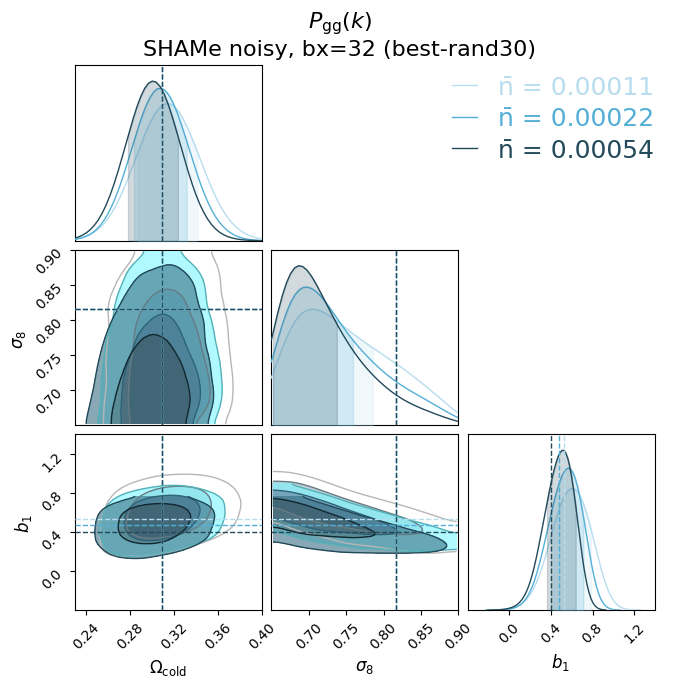

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00054_pred.npy


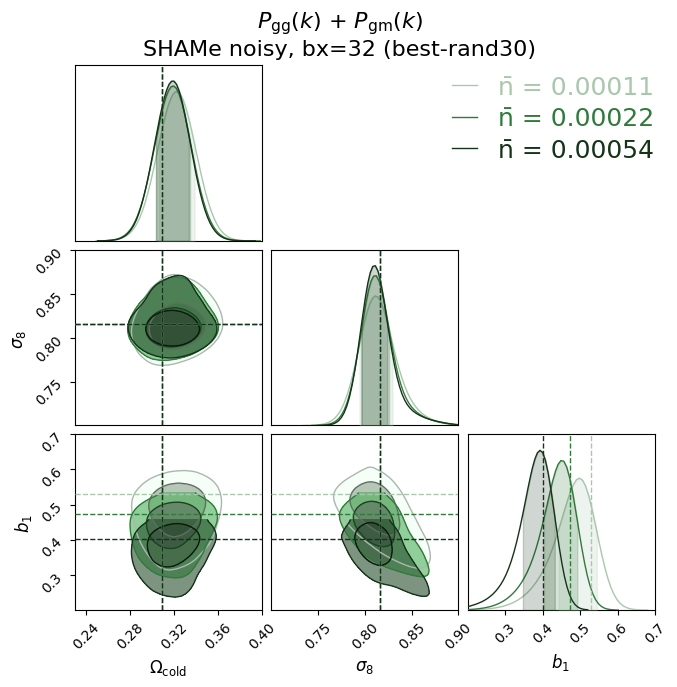

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00054_pred.npy


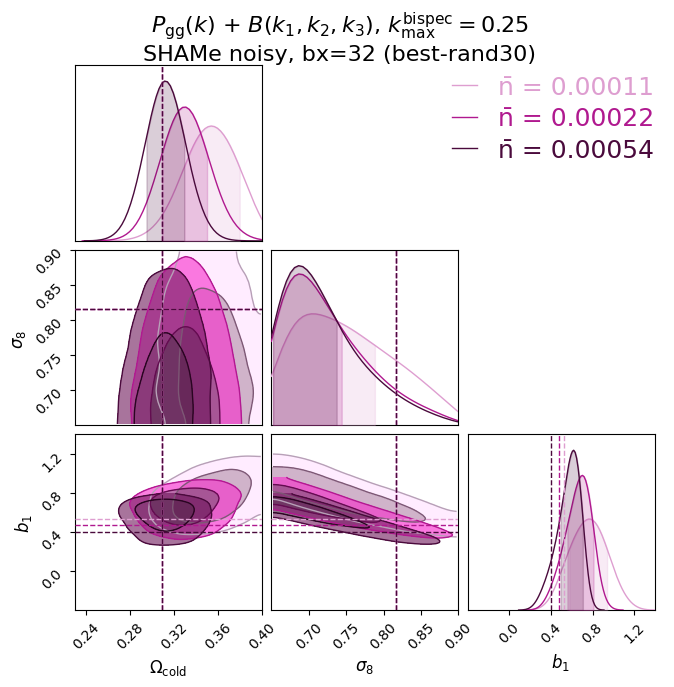

fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00011_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00054_pred.npy


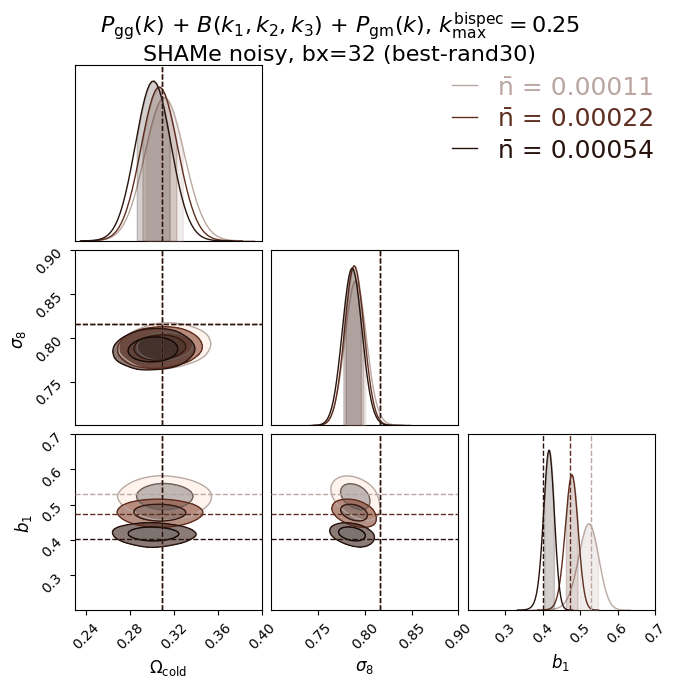

In [5]:
import matplotlib.colors as mcolors


def _nbar_shades(hex_base: str):
    """Light → mid → dark for increasing n̄ (blend toward white / base / black)."""
    rgb = np.array(mcolors.to_rgb(hex_base))
    return [
        mcolors.to_hex(0.42 * rgb + 0.58 * np.ones(3)),
        mcolors.to_hex(rgb),
        mcolors.to_hex(0.42 * rgb + 0.58 * np.zeros(3)),
    ]


def _stat_label_for_idx(idx: int) -> str:
    parts = [utils_plot.get_stat_label(statistics_arr[idx])]
    if tags_mask_inf[idx]:
        parts.append(utils_plot.labels_mask[tags_mask_inf[idx]])
    return ", ".join(parts)


for idx_stat in range(len(statistics_arr)):
    key = tuple(statistics_arr[idx_stat])
    base_col = utils_plot.color_dict_statistics[key]
    colors_nbar = _nbar_shades(base_col)

    tag_stat = f'_{"_".join(statistics_arr[idx_stat])}' + tags_mask_inf[idx_stat]
    tag_inf = tags_inf_noisy[idx_stat]
    stat_label = _stat_label_for_idx(idx_stat)

    tags_test_overlay = [
        utils_plot.setup_shame_mock_test_tags(
            tag_stats_arr=[tag_stat],
            data_mode_test=DATA_MODE_TEST_SHAME,
            tag_mock=tm,
        )[0]
        for tm in TAG_MOCK_SHAME_LIST
    ]
    labels_overlay = [f"n̄ = {lbl}" for lbl in NBAR_LABELS]

    truth_locs = []
    for tag_mock in TAG_MOCK_SHAME_LIST:
        theta_ood = data_loader.load_theta_ood(
            DATA_MODE_TEST_SHAME,
            tag_mock,
            cosmo_param_names_vary=cosmo_param_names_vary_n,
            bias_param_names_vary=bias_param_names_vary_n,
        )
        theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
        idxs_zoom = [param_names_vary_n.index(pn) for pn in PARAM_NAMES_ZOOM]
        theta_show = theta_obs_true[idxs_zoom]
        truth_locs.append(dict(zip(PARAM_NAMES_ZOOM, theta_show)))

    title_overlay = stat_label + "\n" + f"SHAMe noisy, bx={bx} (best-rand30)"

    # pk (0) and pk+bispec (2): mid b1 window, sigma8 full; pk+pgm / pk+bispec+pgm: narrow
    extents_plot = extents_mid if idx_stat in (0, 2) else extents_narrow

    plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=None,
        inf_methods=["sbi"] * len(TAG_MOCK_SHAME_LIST),
        tags_inf=[tag_inf] * len(TAG_MOCK_SHAME_LIST),
        tags_test=tags_test_overlay,
        colors=colors_nbar,
        labels=labels_overlay,
        title=title_overlay,
        extents=extents_plot,
        unreparameterize=True,
        truth_locations=truth_locs,
        truth_colors=colors_nbar,
    )
